In [ ]:
## Markdown
# NAV Return Correlation Matrix

## Objective
- Compute daily NAV returns.
- Select 10 mutual fund schemes.
- Calculate pairwise correlation of daily returns.
- Visualize using a Seaborn heatmap.

In [1]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
## Load Dataset
df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

In [3]:
## Check Dataset
print(df.shape)

print(df.columns)

df.head()

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='object')


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
## Convert Date
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


In [5]:
## Select 10 Funds
selected_funds = df["amfi_code"].unique()[:10]

df10 = df[df["amfi_code"].isin(selected_funds)]

print(selected_funds)

[119551 119552 119598 119599 119120 100016 125497 100033 125498 100025]


In [6]:
## Create Pivot Table
pivot_df = df10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_df.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [7]:
# Calculate Daily Returns
returns = pivot_df.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660
2022-01-10,-0.008639,0.006791,0.006277,-0.000353,-0.001548,0.009465,0.051113,0.033761,0.003057,-0.019536


In [8]:
# Correlation Matrix
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


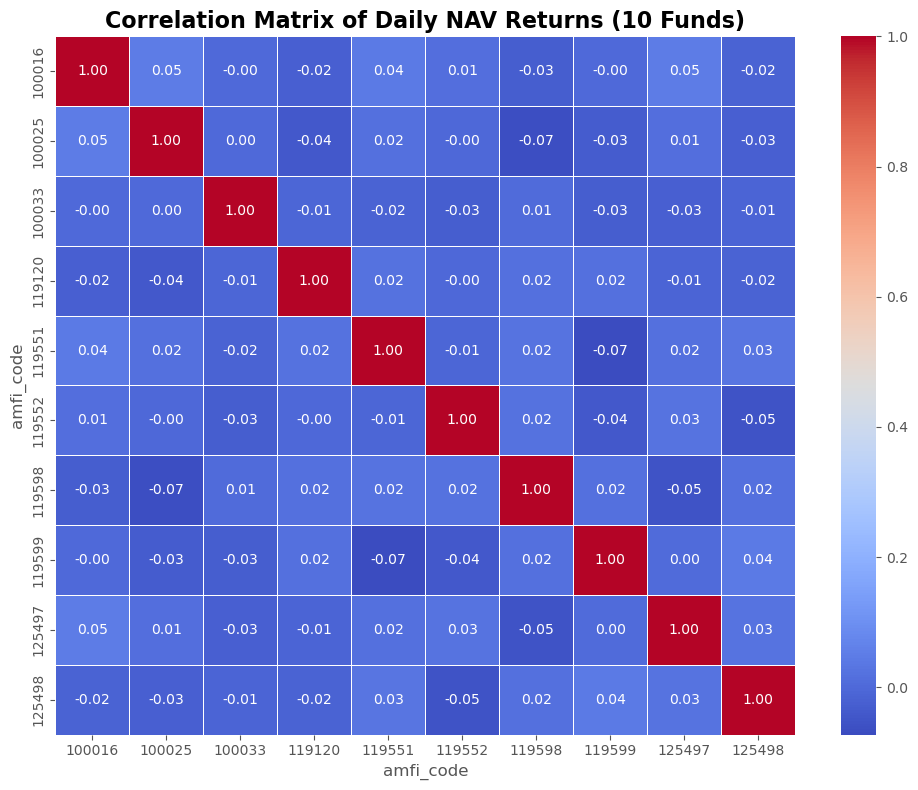

In [9]:
# Plot Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily NAV Returns (10 Funds)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/11_nav_return_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()